# Import Libraries
# Purpose:
# To import the Python libraries required for data cleaning, analysis, visualization, feature engineering, and preprocessing.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Upload Dataset
# Purpose:
# To upload the dataset from your computer into Google Colab.

In [123]:
from google.colab import files

uploaded = files.upload()

Saving Highway-Rail_Grade_Crossing_Accident_Data.csv to Highway-Rail_Grade_Crossing_Accident_Data (1).csv


# Load Dataset
# Purpose:
# To read the uploaded CSV file into a Pandas DataFrame so we can work with the data.

In [125]:
df = pd.read_csv("/content/Highway-Rail_Grade_Crossing_Accident_Data.csv")

print("Dataset loaded successfully")
print(df.shape)

/tmp/ipykernel_5438/3597468226.py:1: DtypeWarning: Columns (6,7,8,25,26,38,42,50,51,52,53,59,64,69,87,88,89,95,97,98,99,100,101,106,126,127,128,129,130,133,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Highway-Rail_Grade_Crossing_Accident_Data.csv")


Dataset loaded successfully
(239487, 141)


# Display First Records
# Purpose:
# To view the first few rows and understand the structure and type of information in the dataset.

In [126]:
df.head()


,Railroad Code,Railroad Name,Report Year,Incident Number,Incident Year,Incident Month,Other Railroad Code,Other Railroad Name,Other Incident Number,Other Incident Year,...,Total Killed Form 57,Total Injured Form 57,Railroad Type,Joint Code,Total Killed Form 55A,Total Injured Form 55A,District,Whistle Ban Code,Whistle Ban,Report Key
0,BNSF,BNSF Railway Company,2009,CA0109200,9,1,NaN,NaN,NaN,NaN,...,0,1,1L,1,0,1,7.0,2.0,No,BNSFCA0109200200901
1,BNSF,BNSF Railway Company,2009,CA0109201,9,1,NaN,NaN,NaN,NaN,...,1,6,1L,1,1,6,7.0,2.0,No,BNSFCA0109201200901
2,NS,Norfolk Southern Railway Company,2020,139633,20,11,NaN,NaN,NaN,NaN,...,0,0,1,1,0,0,3.0,NaN,NaN,NS139633202011
3,BNSF,BNSF Railway Company,2008,CA0208200,8,2,NaN,NaN,NaN,NaN,...,0,2,1L,1,0,2,7.0,2.0,No,BNSFCA0208200200802
4,BNSF,BNSF Railway Company,2008,CA0208201,8,2,NaN,NaN,NaN,NaN,...,0,1,1L,1,0,1,7.0,2.0,No,BNSFCA0208201200802


# Dataset Information
# Purpose:
# To check the number of rows, columns, data types, and general dataset structure.

In [129]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 239487
Columns: 141
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239487 entries, 0 to 239486
Columns: 141 entries, Railroad Code to Report Key
dtypes: float64(50), int64(12), object(79)
memory usage: 257.6+ MB


# Missing Values Percentage
# Purpose:
# To calculate the percentage of missing values in each affected column.

In [131]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Crossing Warning Expanded 9          239487
Crossing Warning Expanded Code 9     239487
Crossing Warning Expanded Code 10    239487
Crossing Warning Expanded Code 11    239487
Crossing Warning Expanded Code 8     239487
                                      ...  
Railroad Name                             8
State Name                                5
State Code                                3
Crossing Warning Expanded Code 12         2
Temperature                               1
Length: 125, dtype: int64


# Missing Values Percentage
# Purpose:
# To calculate the percentage of missing values in each affected column.

In [132]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

Crossing Warning Expanded 9          100.000000
Crossing Warning Expanded Code 9     100.000000
Crossing Warning Expanded Code 10    100.000000
Crossing Warning Expanded Code 11    100.000000
Crossing Warning Expanded Code 8     100.000000
                                        ...    
Railroad Name                          0.003340
State Name                             0.002088
State Code                             0.001253
Crossing Warning Expanded Code 12      0.000835
Temperature                            0.000418
Length: 125, dtype: float64


# Statistics Before Cleaning
# Purpose:
# To generate descriptive statistics before preprocessing so we can compare the dataset before and after cleaning.



In [136]:
print("Statistics Before Preprocessing:")
df.describe(include="all").T

Statistics Before Preprocessing:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Railroad Code,239487,1028,UP,22762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Railroad Name,239479,1021,Union Pacific Railroad Company,22762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Report Year,239487.0,NaN,NaN,NaN,1989.534543,12.351254,1975.0,1979.0,1986.0,1997.0,2021.0
Incident Number,239487,203114,1,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Year,239487.0,NaN,NaN,NaN,67.588049,31.786973,0.0,75.0,80.0,87.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...
Total Injured Form 55A,239487.0,NaN,NaN,NaN,0.371916,0.923655,0.0,0.0,0.0,1.0,101.0
District,214201.0,NaN,NaN,NaN,4.284975,1.733065,0.0,3.0,4.0,5.0,8.0
Whistle Ban Code,42855.0,NaN,NaN,NaN,2.015751,0.316337,1.0,2.0,2.0,2.0,3.0
Whistle Ban,42855,3,No,38556,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Check Duplicate Records
# Purpose:
# To find duplicate rows that may represent the same incident more than once.

In [137]:
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 2


# Purpose: Remove Duplicate Records
# To remove duplicate records and make sure each record is counted only once.

In [138]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (239485, 141)


# Purpose: Clean Column Names
# To convert column names into a consistent format that is easier to use in Python.

In [139]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['railroad_code', 'railroad_name', 'report_year', 'incident_number', 'incident_year', 'incident_month', 'other_railroad_code', 'other_railroad_name', 'other_incident_number', 'other_incident_year', 'other_incident_month', 'maintenance_incident_railroad_code', 'maintenance_railroad_name', 'maintainance_incident_number', 'maintenance_incident_year', 'maintenance_incident_month', 'grade_crossing_id', 'date', 'time', 'month', 'day', 'hour', 'minute', 'am/pm', 'nearest_station', 'division', 'subdivision', 'county_code', 'county_name', 'state_code', 'state_name', 'city_name', 'highway_name', 'public/private_code', 'public/private', 'highway_user_code', 'highway_user', 'estimated_vehicle_speed', 'vehicle_direction_code', 'vehicle_direction', 'highway_user_position_code', 'highway_user_position', 'equipment_involved_code', 'equipment_involved', 'railroad_car_unit_position', 'equipment_struck_code', 'equipment_struck', 'hazmat_involvement_code', 'hazmat_involvement', 'hazm

# Purpose: Replace Empty Values
# To convert empty strings into NaN so Pandas can identify and handle them as missing values.

In [140]:
df = df.replace(r'^\s*$', np.nan, regex=True)
print("Empty values converted to NaN")

Empty values converted to NaN


# Purpose: Convert Date
# To convert the Date column into a proper datetime format for date-based feature engineering.

In [171]:
if "date" in df.columns:
    # Example format for '2021-05-18' -> '%Y-%m-%d' or '05/18/2021' -> '%m/%d/%Y'
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")
    print("Date column data type:", df["date"].dtype)

Date column data type: datetime64[ns]


# Purpose: Convert Numerical Columns
# To convert important numerical columns into numeric data types so mathematical calculations can be performed correctly.

In [142]:
# Purpose:
# To convert important numerical columns into numeric data types so mathematical calculations can be performed correctly.

numeric_columns = [
    "user_age",
    "estimated_vehicle_speed",
    "train_speed",
    "vehicle_damage_cost",
    "number_vehicle_occupants",
    "number_of_cars",
    "number_of_locomotive_units",
    "temperature"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numerical columns converted")

Numerical columns converted


# Purpose: Handle Numerical Missing Values
# To fill missing numerical values using the median, which is less affected by extreme values.

In [143]:
for col in numeric_columns:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Numerical missing values handled")

Numerical missing values handled


# Purpose: Handle Categorical Missing Values
# To replace missing categorical values with "Unknown" instead of losing those records.

In [144]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("Categorical missing values handled")

Categorical missing values handled


# Purpose: Check Missing Values Again
# To verify that missing values have been successfully handled.

In [145]:
remaining_missing = df.isnull().sum().sum()
print("Remaining missing values:", remaining_missing)

Remaining missing values: 4532893


# Purpose: Detect Outliers Using Boxplots
# To visually identify extreme values in important numerical columns.

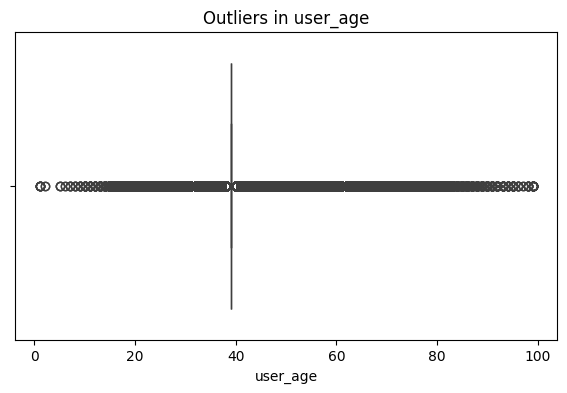

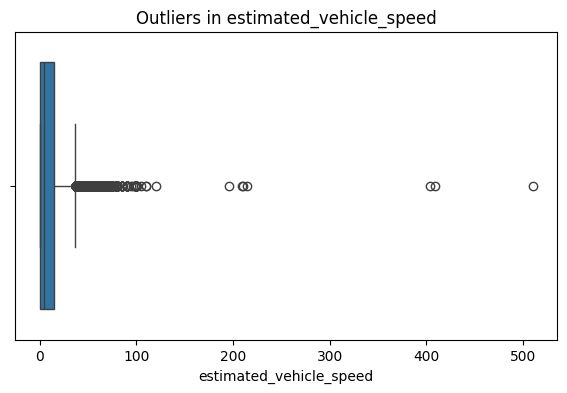

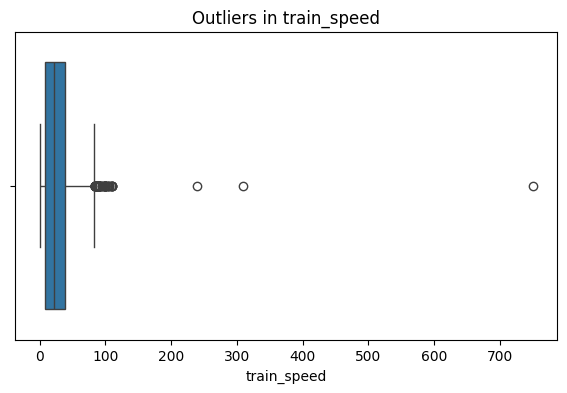

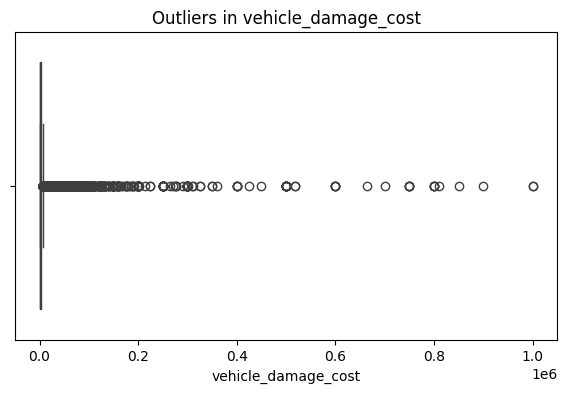

In [146]:
outlier_columns = [
    "user_age",
    "estimated_vehicle_speed",
    "train_speed",
    "vehicle_damage_cost"
]

for col in outlier_columns:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(x=df[col])
        plt.title("Outliers in " + col)
        plt.show()

# Purpose: Handle Outliers Using IQR
# To reduce the effect of extreme values using the Interquartile Range (IQR) method.

In [147]:
for col in outlier_columns:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

print("Outliers handled using IQR method")

Outliers handled using IQR method


# Purpose: Create Incident DateTime
# To combine the Date and Time columns into one datetime feature that can be used for time-based analysis.

In [148]:
if "date" in df.columns and "time" in df.columns:
    df["incident_datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"].astype(str),
        errors="coerce"
    )
    display(df[["date", "time", "incident_datetime"]].head())
else:
    print("Warning: 'date' or 'time' column missing.")

,date,time,incident_datetime
0,1/14/2009,7:40 AM,2009-01-14 07:40:00
1,1/17/2009,5:52 PM,2009-01-17 17:52:00
2,11/3/2020,6:40 PM,2020-11-03 18:40:00
3,2/9/2008,9:00 AM,2008-02-09 09:00:00
4,2/16/2008,12:10 PM,2008-02-16 12:10:00


# Purpose: Create Is_Night
# To identify whether the railroad incident happened during nighttime.

In [149]:
if "hour" in df.columns:
    df["is_night"] = df["hour"].apply(
        lambda x: 1 if (pd.notnull(x) and (x < 6 or x >= 18)) else 0
    )
    display(df[["hour", "is_night"]].head())
elif "incident_datetime" in df.columns:
    df["is_night"] = df["incident_datetime"].dt.hour.apply(
        lambda x: 1 if (pd.notnull(x) and (x < 6 or x >= 18)) else 0
    )
    print("Created 'is_night' using 'incident_datetime'.")

,hour,is_night
0,7,0
1,5,1
2,6,0
3,9,0
4,12,0


# Purpose: Create Is_Weekend
# To identify whether the incident occurred on a weekend.

In [150]:
if "incident_datetime" in df.columns:
    df["is_weekend"] = df["incident_datetime"].dt.dayofweek.apply(
        lambda x: 1 if x >= 5 else 0
    )
    display(df[["incident_datetime", "is_weekend"]].head())
elif "date" in df.columns:
    df["is_weekend"] = df["date"].dt.dayofweek.apply(
        lambda x: 1 if x >= 5 else 0
    )
    print("Created 'is_weekend' using 'date'.")

,incident_datetime,is_weekend
0,2009-01-14 07:40:00,0
1,2009-01-17 17:52:00,1
2,2020-11-03 18:40:00,0
3,2008-02-09 09:00:00,1
4,2008-02-16 12:10:00,1


# Purpose: Create Speed Difference
# To calculate the difference between vehicle speed and train speed as a new numerical feature.

In [151]:
if "estimated_vehicle_speed" in df.columns and "train_speed" in df.columns:
    df["speed_difference"] = (
        df["estimated_vehicle_speed"] - df["train_speed"]
    )
    display(df[["estimated_vehicle_speed", "train_speed", "speed_difference"]].head())

,estimated_vehicle_speed,train_speed,speed_difference
0,4.0,55.0,-51.0
1,0.0,59.0,-59.0
2,0.0,5.0,-5.0
3,1.0,31.0,-30.0
4,5.0,70.0,-65.0


# Purpose: Create Total Injuries
# To combine different injury counts into one feature representing the total number of injuries.

In [152]:
injury_columns = [
    "crossing_users_injured_for_reporting_railroad",
    "employees_injured_for_reporting_railroad",
    "passengers_injured_for_reporting_railroad"
]

valid_injuries = [col for col in injury_columns if col in df.columns]

for col in valid_injuries:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

if valid_injuries:
    df["total_injuries"] = df[valid_injuries].sum(axis=1)
else:
    df["total_injuries"] = 0

df["total_injuries"].head()

/tmp/ipykernel_5438/2801175171.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_injuries"] = df[valid_injuries].sum(axis=1)


,total_injuries
0,1.0
1,6.0
2,0.0
3,2.0
4,1.0


# Purpose: Create Total Fatalities
# To combine different death counts into one feature representing total fatalities.

In [153]:
death_columns = [
    "crossing_users_killed_for_reporting_railroad",
    "employees_killed_for_reporting_railroad",
    "passengers_killed_for_reporting_railroad"
]

valid_deaths = [col for col in death_columns if col in df.columns]

for col in valid_deaths:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

if valid_deaths:
    df["total_fatalities"] = df[valid_deaths].sum(axis=1)
else:
    df["total_fatalities"] = 0

df["total_fatalities"].head()

/tmp/ipykernel_5438/1071088748.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_fatalities"] = df[valid_deaths].sum(axis=1)


,total_fatalities
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0


# Purpose: Create Damage Per Occupant
# To calculate the average vehicle damage associated with each vehicle occupant.

In [154]:
if "vehicle_damage_cost" in df.columns and "number_vehicle_occupants" in df.columns:
    df["damage_per_occupant"] = (
        df["vehicle_damage_cost"] /
        df["number_vehicle_occupants"].replace(0, np.nan)
    )
    df["damage_per_occupant"] = df["damage_per_occupant"].fillna(0)
    display(df["damage_per_occupant"].head())

/tmp/ipykernel_5438/2758177335.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["damage_per_occupant"] = (


,damage_per_occupant
0,2000.000000
1,714.285714
2,800.000000
3,400.000000
4,2000.000000


# Purpose: Create Accident Severity
# To create a combined severity feature using injuries and fatalities.

In [155]:
if "total_injuries" in df.columns and "total_fatalities" in df.columns:
    df["accident_severity"] = (
        df["total_injuries"] +
        (df["total_fatalities"] * 3)
    )
    display(df[["total_injuries", "total_fatalities", "accident_severity"]].head())

/tmp/ipykernel_5438/4273304691.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["accident_severity"] = (


,total_injuries,total_fatalities,accident_severity
0,1.0,0.0,1.0
1,6.0,1.0,9.0
2,0.0,0.0,0.0
3,2.0,0.0,2.0
4,1.0,0.0,1.0


# Purpose: Display All New Features
# To verify that the required new meaningful features have been successfully created.

1.   List item
2.   List item



In [156]:
new_features = [
    "incident_datetime",
    "is_night",
    "is_weekend",
    "speed_difference",
    "total_injuries",
    "total_fatalities",
    "damage_per_occupant",
    "accident_severity"
]

valid_new_features = [col for col in new_features if col in df.columns]
display(df[valid_new_features].head())


,incident_datetime,is_night,is_weekend,speed_difference,total_injuries,total_fatalities,damage_per_occupant,accident_severity
0,2009-01-14 07:40:00,0,0,-51.0,1.0,0.0,2000.000000,1.0
1,2009-01-17 17:52:00,1,1,-59.0,6.0,1.0,714.285714,9.0
2,2020-11-03 18:40:00,0,0,-5.0,0.0,0.0,800.000000,0.0
3,2008-02-09 09:00:00,0,1,-30.0,2.0,0.0,400.000000,2.0
4,2008-02-16 12:10:00,0,1,-65.0,1.0,0.0,2000.000000,1.0


# Purpose: Select Categorical Variables
# To select important categorical variables that need to be converted into numerical form.

In [157]:
encoding_columns = [
    "state_name",
    "weather_condition",
    "equipment_type",
    "highway_user",
    "user_gender",
    "railroad_type"
]

encoding_columns = [
    col for col in encoding_columns if col in df.columns
]

print("Categorical columns selected for encoding:")
print(encoding_columns)

Categorical columns selected for encoding:
['state_name', 'weather_condition', 'equipment_type', 'highway_user', 'user_gender', 'railroad_type']


# Purpose: Encode Categorical Variables
# To convert categorical text values into numerical values that can be processed by machine-learning algorithms.

In [158]:
label_encoders = {}

for col in encoding_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    label_encoders[col] = encoder

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


# Purpose: Select Numerical Features
# To select numerical features that will be standardized.

In [159]:
scale_columns = [
    "user_age",
    "estimated_vehicle_speed",
    "train_speed",
    "vehicle_damage_cost",
    "number_vehicle_occupants",
    "number_of_cars",
    "temperature",
    "speed_difference",
    "total_injuries",
    "total_fatalities",
    "damage_per_occupant",
    "accident_severity"
]

scale_columns = [
    col for col in scale_columns if col in df.columns
]

print("Numerical features selected for scaling:")
print(scale_columns)

Numerical features selected for scaling:
['user_age', 'estimated_vehicle_speed', 'train_speed', 'vehicle_damage_cost', 'number_vehicle_occupants', 'number_of_cars', 'temperature', 'speed_difference', 'total_injuries', 'total_fatalities', 'damage_per_occupant', 'accident_severity']


# Purpose: Standardize Numerical Features
# To put numerical features on a similar scale using StandardScaler.

In [160]:
if scale_columns:
    scaler = StandardScaler()
    df[scale_columns] = scaler.fit_transform(df[scale_columns])
    print("Numerical features standardized successfully!")

Numerical features standardized successfully!


# Purpose: Display Final Dataset
# To check the final structure and confirm that preprocessing has been applied.

In [161]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (239485, 149)


,railroad_code,railroad_name,report_year,incident_number,incident_year,incident_month,other_railroad_code,other_railroad_name,other_incident_number,other_incident_year,...,whistle_ban,report_key,incident_datetime,is_night,is_weekend,speed_difference,total_injuries,total_fatalities,damage_per_occupant,accident_severity
0,BNSF,BNSF Railway Company,2009,CA0109200,9,1,Unknown,Unknown,Unknown,NaN,...,No,BNSFCA0109200200901,2009-01-14 07:40:00,0,0,-1.679277,0.681453,-0.268997,0.199868,0.224934
1,BNSF,BNSF Railway Company,2009,CA0109201,9,1,Unknown,Unknown,Unknown,NaN,...,No,BNSFCA0109201200901,2009-01-17 17:52:00,1,1,-2.043321,6.104389,2.431741,-0.401825,5.686094
2,NS,Norfolk Southern Railway Company,2020,139633,20,11,Unknown,Unknown,Unknown,NaN,...,Unknown,NS139633202011,2020-11-03 18:40:00,0,0,0.413979,-0.403134,-0.268997,-0.361712,-0.457712
3,BNSF,BNSF Railway Company,2008,CA0208200,8,2,Unknown,Unknown,Unknown,NaN,...,No,BNSFCA0208200200802,2008-02-09 09:00:00,0,1,-0.723660,1.766040,-0.268997,-0.548906,0.907579
4,BNSF,BNSF Railway Company,2008,CA0208201,8,2,Unknown,Unknown,Unknown,NaN,...,No,BNSFCA0208201200802,2008-02-16 12:10:00,0,1,-2.316355,0.681453,-0.268997,0.199868,0.224934


# Purpose: Check Final Data Types
# To verify that columns now have appropriate data types after preprocessing.

In [162]:
df.dtypes

,0
railroad_code,object
railroad_name,object
report_year,int64
incident_number,object
incident_year,int64
...,...
speed_difference,float64
total_injuries,float64
total_fatalities,float64
damage_per_occupant,float64


# Purpose: Check Remaining Missing Values
# To confirm that the cleaned dataset does not contain unwanted missing values.

In [163]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 4511653


# Purpose: Statistics After Preprocessing
# To generate descriptive statistics after preprocessing and compare them with the original statistics.

In [164]:
print("Statistics After Preprocessing:")
df.describe().T

Statistics After Preprocessing:


,count,mean,min,25%,50%,75%,max,std
report_year,239485.0,1989.534438,1975.0,1979.0,1986.0,1997.0,2021.0,12.351253
incident_year,239485.0,67.588596,0.0,75.0,80.0,87.0,99.0,31.786541
incident_month,239485.0,6.520555,0.0,3.0,7.0,10.0,12.0,3.630536
other_incident_year,4554.0,79.92007,4.0,77.0,80.0,83.0,95.0,5.722995
other_incident_month,4554.0,6.40975,1.0,3.0,6.0,10.0,12.0,3.631361
...,...,...,...,...,...,...,...,...
speed_difference,239485.0,-0.0,-3.135455,-0.72366,0.186451,0.641506,2.347965,1.000002
total_injuries,239485.0,-0.0,-0.403134,-0.403134,-0.403134,0.681453,109.140166,1.000002
total_fatalities,239485.0,-0.0,-0.268997,-0.268997,-0.268997,-0.268997,32.139861,1.000002
damage_per_occupant,239485.0,0.0,-0.736099,-0.736099,-0.502107,0.199868,2.563183,1.000002


# Purpose: Final Statistics Comparison
# To display statistics of the standardized numerical features after preprocessing.

In [165]:
if scale_columns:
    comparison = df[scale_columns].describe().T
    display(comparison)

,count,mean,std,min,25%,50%,75%,max
user_age,239485.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
estimated_vehicle_speed,239485.0,6.123808e-17,1.000002,-0.894754,-0.894754,-0.456548,0.419865,2.391793
train_speed,239485.0,5.150645e-17,1.000002,-1.350152,-0.905778,-0.128124,0.760623,3.260226
vehicle_damage_cost,239485.0,-3.228054e-17,1.000002,-0.880306,-0.751768,-0.451847,0.405070,2.140326
number_vehicle_occupants,239485.0,-9.583285e-18,1.000002,-0.229868,-0.039194,-0.039194,-0.039194,476.453973
number_of_cars,239485.0,-4.533517e-17,1.000002,-1.007645,-0.887004,-0.356184,0.753711,21.769345
temperature,239485.0,1.039623e-16,1.000002,-5.661385,-0.703218,0.159072,0.805789,35.081811
speed_difference,239485.0,-3.322997e-18,1.000002,-3.135455,-0.723660,0.186451,0.641506,2.347965
total_injuries,239485.0,-1.163049e-17,1.000002,-0.403134,-0.403134,-0.403134,0.681453,109.140166
total_fatalities,239485.0,-3.216186e-17,1.000002,-0.268997,-0.268997,-0.268997,-0.268997,32.139861


# Purpose: Save Cleaned Dataset
# To save the final analysis-ready dataset as a CSV file.

In [166]:
df.to_csv("cleaned_railroad_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Purpose: Download Dataset
# To download the cleaned dataset from Google Colab to your computer.

In [167]:
from google.colab import files
files.download("cleaned_railroad_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Purpose: Import Pipeline Libraries
# To import Scikit-learn tools required to create an automated preprocessing pipeline.

In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Pipeline libraries imported successfully!")

Pipeline libraries imported successfully!


# Purpose: Create Preprocessing Pipeline
# To automatically handle missing values, standardize numerical features, and encode categorical features.

In [169]:
numeric_features = [
    "user_age",
    "estimated_vehicle_speed",
    "train_speed",
    "vehicle_damage_cost",
    "number_vehicle_occupants"
]

categorical_features = [
    "state_name",
    "weather_condition",
    "equipment_type",
    "highway_user",
    "user_gender"
]

numeric_features = [
    col for col in numeric_features if col in df.columns
]
categorical_features = [
    col for col in categorical_features if col in df.columns
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


# Purpose: Run Automated Pipeline
# To apply the complete automated preprocessing pipeline to the selected features.

In [170]:
pipeline_cols = numeric_features + categorical_features

if pipeline_cols:
    X = df[pipeline_cols]
    X_processed = preprocessor.fit_transform(X)
    print("Pipeline completed successfully!")
    print("Processed data shape:", X_processed.shape)
else:
    print("Error: No valid pipeline features available in the current dataset.")

Pipeline completed successfully!
Processed data shape: (239485, 94)
